In [26]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import torch
from tqdm import tqdm 
from models.scs import * 
from metrics import treatment_effect

In [57]:
# Load PEACE dataset
from datasets_retrospective import load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='datasets/ACCORD/', intervention='Glycemia')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 21)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:741: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_re

In [28]:
# Specify categorical and numeric features used for training the model
# cat_feats=['Baseline_Smoke_status', 'Baseline_History_Cardiovascular_Disease']
# num_feats=['Baseline_Glucose']

In [58]:
# Preprocess feature data
from preprocessing import Preprocessor
features = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [59]:
# Hyper-parameters to train model
k = 2 # number of underlying base survival phenotypes
random_seed = 105
n_epochs = 100 # number of training epochs
step_size = 1e-5

In [60]:
from models.scs.model import SparseCoxSubgroup

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model on all data
model = SparseCoxSubgroup(k=k, random_seed=random_seed, n_epochs=n_epochs, n_restarts=1, step_size=step_size, alpha=0.)

model.fit(features.values, outcomes.time.values, outcomes.event.values, (intervention=='Intensive Glycemia').values)

Restarts:   0%|          | 0/1 [00:00<?, ?it/s]


2.717739369434736
2.603280326296662
2.4918272168279567
2.385657684770441
2.279830755722132
2.166255809333163
2.076156351409799
1.9896680018434667


1.9123083134986443
1.8497929162379099
1.8072413610801943
1.767725170762589
1.731066920978545
1.7128765452115173
1.6909864696893173
1.6742555790281684


1.6572581937181883
1.640446300233385
1.6294428480204943
1.6246685933725469
1.610851525163786
1.602854705172006
1.5956878838904003
1.5889983864409134
1.5810106693601789


1.5739083055303973
1.5678851481453446
1.5568964144598154
1.5549689463216645
1.551646525231047
1.5451499815374063
1.5406063386547686
1.5370053245203819


...

1.4495080953575032
1.4477503653907002
1.4488231590124512
1.4480563632027204
1.4484418564126187
1.4476915372643178
1.4443029213717407
1.4425645676064205


1.4431764468873085
1.4425163221425938
1.4402661606963787
1.440674743811948
1.43994638696716
1.437245685690076
1.4382969047286764
1.4385130931445493


1.437708622128455
1.439528821906488
1.4350600721061477
1.4343181572194732
1.4334094978558187
1.434409317961353
1.4314395537218894
1.4322856890764304


Restarts: 100%|██████████| 1/1 [00:02<00:00,  2.68s/it]

1.4326129800627232
1.4280582140252556


In [54]:
# model.parameters['gate']

tensor([[0.0605, 0.0494],
        [0.1479, 0.1649],
        [0.2733, 0.2584],
        [0.7585, 0.7571],
        [0.6947, 0.7875],
        [0.6138, 0.6367],
        [0.3122, 0.2391],
        [0.2517, 0.2619],
        [0.5597, 0.5651],
        [0.8761, 0.8461],
        [0.4079, 0.4552],
        [0.5632, 0.3983],
        [0.2565, 0.1121],
        [0.4037, 0.4887],
        [0.1514, 0.0847],
        [0.5235, 0.5425],
        [0.1382, 0.0527],
        [0.1108, 0.2098],
        [0.2914, 0.0816],
        [0.3035, 0.4720],
        [0.5537, 0.4570],
        [0.3987, 0.2193],
        [0.6905, 0.4452],
        [0.1429, 0.3948],
        [0.4699, 0.9225],
        [0.6274, 0.4313],
        [0.5517, 0.8192],
        [0.7887, 0.6571],
        [0.4006, 0.8361],
        [0.6342, 0.3573],
        [0.8579, 0.5325],
        [0.1937, 0.2149],
        [0.1426, 0.0688],
        [0.4121, 0.2418],
        [0.7759, 0.7142],
        [0.6229, 0.8967],
        [0.3360, 0.4447],
        [0.7823, 0.6978],
        [0.4

In [61]:
zeta = model.predict_proba(features.values).argmax(axis=1)

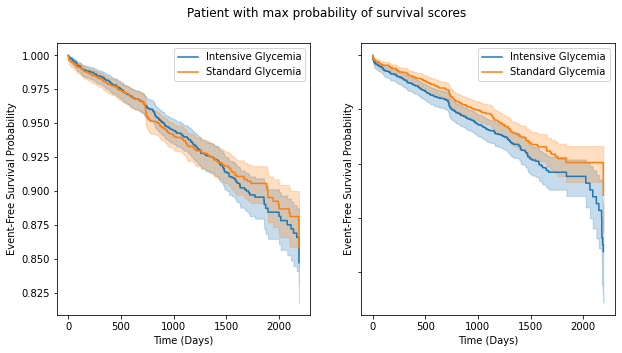

In [62]:
from matplotlib import pyplot as plt
from auton_survival import reporting
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(outcomes[zeta == 0], intervention[zeta == 0], ax=ax1)
reporting.plot_kaplanmeier(outcomes[zeta == 1], intervention[zeta == 1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Intensive Glycemia', 'Standard Glycemia'], loc="upper right")
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

# Split the PEACE data into training and test data
x_train, x_test, y_train, y_test = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='SBP target <120mm Hg'))

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 6552
Number of test data points: 2809


In [36]:
x_tr = x_train.values
t_tr = y_train['time'].values
e_tr = y_train['event'].values
a_tr = intervention[y_train.index]=='SBP target <120mm Hg'

x_te = x_test.values
t_te = y_test['time'].values
e_te = y_test['event'].values
a_te = intervention[y_test.index]=='SBP target <120mm Hg'

In [38]:
from models.scs.model import SparseCoxSubgroup

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model on all data
model = SparseCoxSubgroup(k=k, random_seed=random_seed, n_epochs=n_epochs, n_restarts=1, step_size=step_size, alpha=0.)

model.fit(x_tr, t_tr, e_tr, a_tr.values)

Restarts:   0%|          | 0/1 [00:00<?, ?it/s]

1.7947130679086778
1.7015570294561146
1.5826946191061522
1.5349421024390553
1.4986733939805197
1.484158938269543
1.4687745966727264
1.4554164687774807
1.441051408003171
1.4260073737793515
1.4203576499164086
1.4212548239053777


1.4089865202866103
1.4107009285840977
1.3991768826725115
1.3874319715564134
1.383153352477808
1.3689195333495752
1.368299606960545
1.357179400095207
1.3656624438062996
1.3552985754533051
1.348094168236119
1.3477211647046639


1.3455071890716004
1.340566611957238
1.3347128096150331
1.335352729799909
1.3295701279426202
1.32645102636793
1.3200750991591854
1.3148516135191821
1.3159037842903427
1.3093055063419317
1.3086864909004463
1.3071734447084598
1.303787276780473


1.300721574030675
1.2972048205180273
1.2932442600809604
1.2952772021568555
1.2900790617395463
1.2908890280640988
1.2845664881180414
1.2818219998585725
1.2821926819618823
1.2833695994563166
1.2807759308739
1.2793263757452455
1.2746915952631275


...

1.1549271794990275
1.1542771540621322
1.1538102898371496
1.154710775220601
1.1545268285717616
1.1545293721344585
1.1544447959200366
1.1547804654785343
1.1544530314862862
1.1542365250707542
1.1543220946432826
1.1542806094443576


1.1544488654954186
1.1546883085312356
1.1549624073622267
1.1541504068470583
1.1544444666580005
1.1543329615419642
1.154524655384688
1.1536223964032861
1.1541624779982498
1.15469652634452
1.1540506675561037


1.1545987509199467
1.1545953185652982
1.154677809604227
1.1539351957847497
1.1539477404307217
1.154453712422458
1.154691744509241
1.154319411343706
1.1540722496473985
1.1543297829720012
1.1537797133048966
1.1542678475620984


Restarts: 100%|██████████| 1/1 [00:34<00:00, 34.17s/it]

1.1548394209093777
1.1540513035277695
1.1537387824184415
1.1544907416584946
1.1538611823625904
1.1536924434293014
1.1542282707102907


In [39]:
zeta_probs_train = model.predict_proba(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)
idx_list_0tr = np.where(zeta_train == 0)
idx_list_1tr = np.where(zeta_train == 1)

zeta_probs_test = model.predict_proba(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)
idx_list_0te = np.where(zeta_test == 0)
idx_list_1te = np.where(zeta_test == 1)

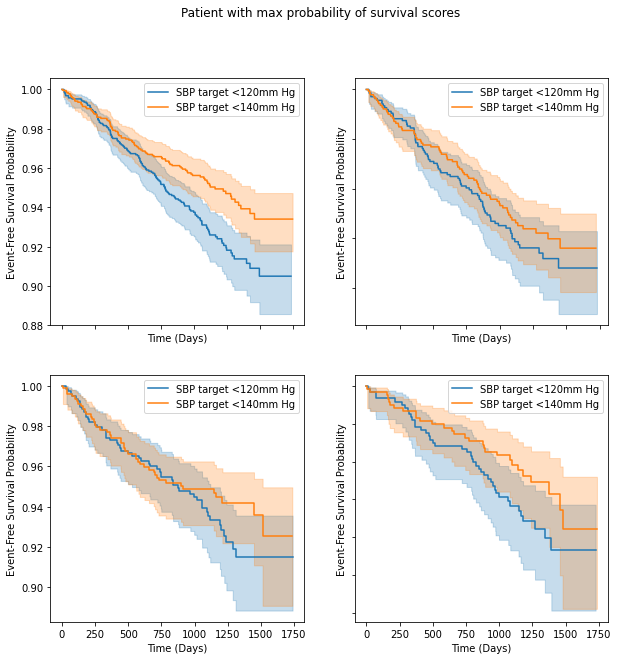

In [40]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize= (10, 10))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(y_train.iloc[idx_list_0tr], a_tr.iloc[idx_list_0tr], ax=ax1)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_1tr], a_tr.iloc[idx_list_1tr], ax=ax2)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_0te], a_te.iloc[idx_list_0te], ax=ax3) 
reporting.plot_kaplanmeier(y_test.iloc[idx_list_1te], a_te.iloc[idx_list_1te], ax=ax4)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['SBP target <120mm Hg', 'SBP target <140mm Hg'], loc="upper right")
plt.show()
# First row is training data
# Second row is test data
# First column is zeta 0
# Second column is zeta 1